In [1]:
!pip -q install "torchmetrics[image]"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 29.3 MB/s eta 0:00:00


#  Generative Models for Images

**Name-** hindvrat singh rao

**Reg number** - 202583677

**CS827**

## Overview / Summary

In this i investigated how model design choices affect the image generation performance using the FashionMNIST dataset.  so i implemented and evaluated three model iterations: a Variational Autoencoder (VAE), a Deep Convolutional GAN (DCGAN), and a Wasserstein GAN with Gradient Penalty (WGAN-GP).

The aim of this was to compare how these model designs impact generation quality of the images. Performance of these models were  assessed using the MiFID metric and supported by qualitative visual inspection of the generated samples.


Overall the experiments showed that the VAE provided a stable baseline but the DCGAN produced sharper images and the strongest overall result and the WGAN-GP improved on the VAE baseline but did not outperform DCGAN in this implementation

## Training and Validation

my notebook shows the full training and validation process for all three model iterations. Each experiment includes the model design, training setup, evaluation results, and a discussion of strengths and limitations.

All models were trained on the same FashionMNIST split so that the comparison was fair across iterations. The training set contained 54,000 images the validation set contained 6,000 images, and the test set contained 10,000 images.





In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, utils
from torchmetrics.image.mifid import MemorizationInformedFrechetInceptionDistance


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:



def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Random seeds set to 42 for exact reproducibility!")

Random seeds set to 42 for exact reproducibility!


### Data preprocessing

FashionMNIST images were converted to tensors and normalised to the range [-1, 1]. The same preprocessing was used across all three iterations to keep the comparison same.



In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.5MB/s]


In [6]:
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))


Train size: 54000
Validation size: 6000
Test size: 10000


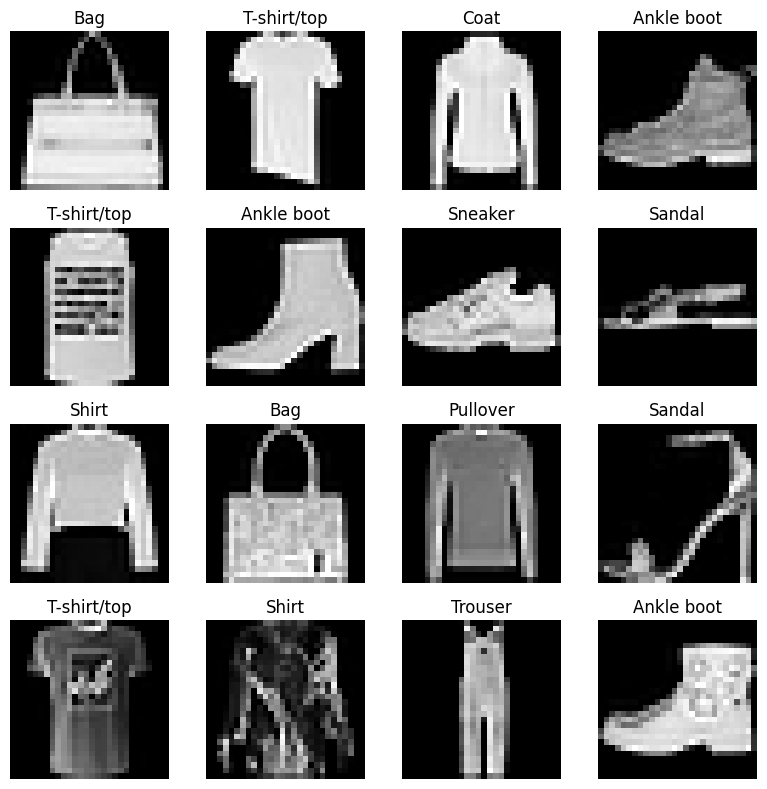

In [7]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    img = (img * 0.5) + 0.5
    ax.imshow(img, cmap="gray")
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()


### Model design

The first model is a Variational Autoencoder (VAE). This was chosen as it provides a strong  baseline for generative modelling .

The VAE consists of an encoder and a decoder The encoder maps the input images into a latent distribution while the decoder reconstructs images from latent vectors from that distribution


### Motivation and hypothesis

my aim for starting with a VAE was to build a stable baseline model before moving to adversarial approaches Since the VAE learns through a reconstruction objective combined with latent space regularisation it is generally bit easier to train than GAN based models.

My thinking was that the VAE would produce stable training curves and recognisable FashionMNIST outputs, but the generated images would likely look blurrier than those from GAN based models.
.

### Training setup

The VAE was trained on the FashionMNIST training split using the same preprocessing pipeline defined earlier.The dataset was divided into training and validation sets so that  the  training progress and generalisation behaviour could both be monitor.



In [8]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),   # 14 -> 28
            nn.Tanh()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(-1, 64, 7, 7)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


In [9]:
def vae_loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss


In [10]:
def train_vae(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0

    for images, _ in loader:
        images = images.to(device)

        optimizer.zero_grad()
        recon_images, mu, logvar = model(images)
        loss, recon_loss, kl_loss = vae_loss_function(recon_images, images, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_loss = total_loss / len(loader.dataset)
    avg_recon = total_recon / len(loader.dataset)
    avg_kl = total_kl / len(loader.dataset)

    return avg_loss, avg_recon, avg_kl


def validate_vae(model, loader, device):
    model.eval()
    total_loss = 0
    total_recon = 0
    total_kl = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)

            recon_images, mu, logvar = model(images)
            loss, recon_loss, kl_loss = vae_loss_function(recon_images, images, mu, logvar)

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

    avg_loss = total_loss / len(loader.dataset)
    avg_recon = total_recon / len(loader.dataset)
    avg_kl = total_kl / len(loader.dataset)

    return avg_loss, avg_recon, avg_kl


In [11]:
latent_dim = 32
learning_rate = 1e-3
num_epochs = 15

vae_model = VAE(latent_dim=latent_dim).to(device)
optimizer_vae = optim.Adam(vae_model.parameters(), lr=learning_rate)

vae_history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
    "val_loss": [],
    "val_recon": [],
    "val_kl": []
}

best_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss, train_recon, train_kl = train_vae(vae_model, train_loader, optimizer_vae, device)
    val_loss, val_recon, val_kl = validate_vae(vae_model, val_loader, device)

    vae_history["train_loss"].append(train_loss)
    vae_history["train_recon"].append(train_recon)
    vae_history["train_kl"].append(train_kl)
    vae_history["val_loss"].append(val_loss)
    vae_history["val_recon"].append(val_recon)
    vae_history["val_kl"].append(val_kl)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(vae_model.state_dict(), "vae_best.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Recon: {train_recon:.4f} | Train KL: {train_kl:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Recon:   {val_recon:.4f} | Val KL:   {val_kl:.4f}")
    print("-" * 60)


Epoch [1/15]
Train Loss: 117.2886 | Train Recon: 90.8797 | Train KL: 26.4089
Val Loss:   84.6789 | Val Recon:   59.3114 | Val KL:   25.3675
------------------------------------------------------------
Epoch [2/15]
Train Loss: 78.9420 | Train Recon: 54.5904 | Train KL: 24.3516
Val Loss:   76.2477 | Val Recon:   50.9426 | Val KL:   25.3050
------------------------------------------------------------
Epoch [3/15]
Train Loss: 73.3704 | Train Recon: 49.8912 | Train KL: 23.4793
Val Loss:   72.6887 | Val Recon:   48.7720 | Val KL:   23.9167
------------------------------------------------------------
Epoch [4/15]
Train Loss: 70.4692 | Train Recon: 47.4935 | Train KL: 22.9756
Val Loss:   69.9101 | Val Recon:   46.3471 | Val KL:   23.5630
------------------------------------------------------------
Epoch [5/15]
Train Loss: 68.6785 | Train Recon: 45.9940 | Train KL: 22.6845
Val Loss:   68.3065 | Val Recon:   45.1195 | Val KL:   23.1870
------------------------------------------------------------

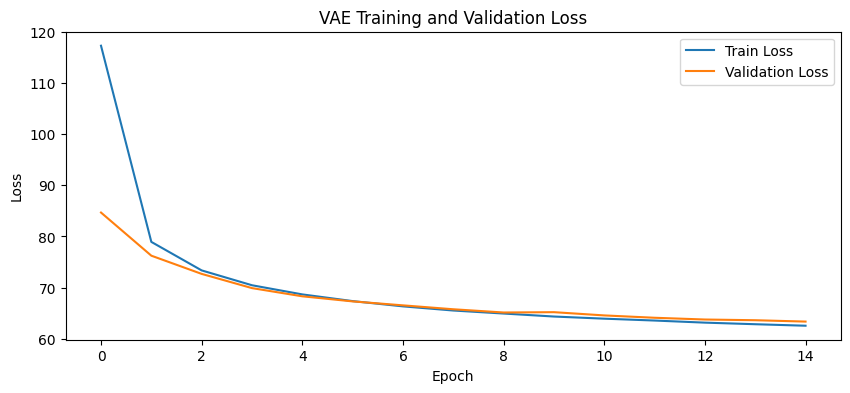

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(vae_history["train_loss"], label="Train Loss")
plt.plot(vae_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training and Validation Loss")
plt.legend()
plt.show()


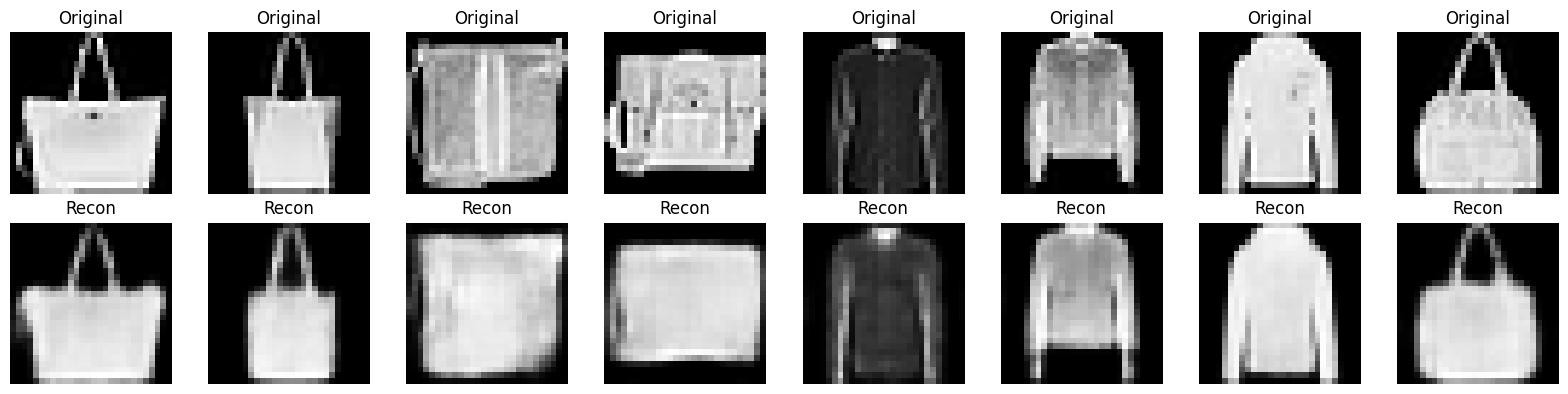

In [13]:
vae_model.load_state_dict(torch.load("vae_best.pth" ))
vae_model.eval()

images, _ = next(iter(val_loader))
images = images[:8].to(device)

with torch.no_grad():
    recon_images, _, _ = vae_model(images)

images = images.cpu()
recon_images = recon_images.cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    original = (images[i].squeeze().numpy() * 0.5) + 0.5
    reconstructed = (recon_images[i].squeeze().numpy() * 0.5) + 0.5

    axes[0, i].imshow(original, cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    axes[1, i].imshow(reconstructed, cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Recon")

plt.tight_layout()
plt.show()


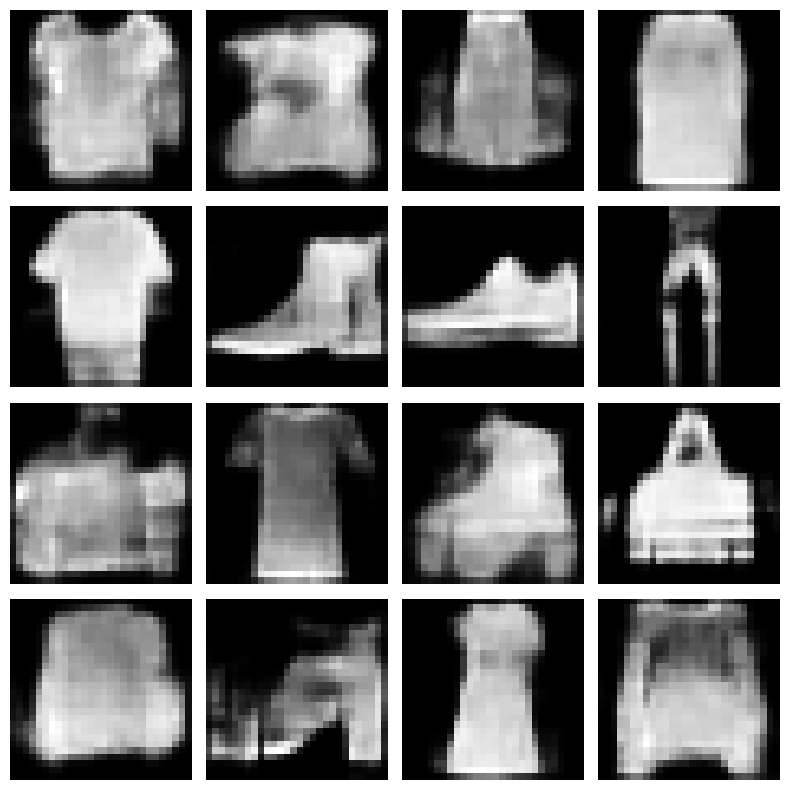

In [14]:
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated_images = vae_model.decode(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = generated_images[i].squeeze().numpy()
    img = (img * 0.5) + 0.5
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [15]:
def prepare_for_mifid(images):
    images = (images + 1) / 2
    images = images.clamp(0, 1)
    images = F.interpolate(images, size=(299, 299), mode="bilinear", align_corners=False)
    images = images.repeat(1, 3, 1, 1)
    images = (images * 255).to(torch.uint8)
    return images

mifid_metric = MemorizationInformedFrechetInceptionDistance(feature=64).to(device)

vae_model.eval()
num_samples = 0
max_samples = 1000

with torch.no_grad():
    for real_images, _ in val_loader:
        real_images = real_images.to(device)
        batch_size_now = real_images.size(0)

        z = torch.randn(batch_size_now, latent_dim).to(device)
        fake_images = vae_model.decode(z)

        real_uint8 = prepare_for_mifid(real_images)
        fake_uint8 = prepare_for_mifid(fake_images)

        mifid_metric.update(real_uint8, real=True)
        mifid_metric.update(fake_uint8, real=False)

        num_samples += batch_size_now
        if num_samples >= max_samples:
            break

vae_mifid = mifid_metric.compute().item()
print("VAE MiFID:", vae_mifid)


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 114MB/s]


VAE MiFID: 1111.5130615234375


### Results and discussion


The VAE provided a stable baseline for the image generation task. The training and validation behaviour suggested that the model learned the overall structure of the FashionMNIST data in a consistent way.

 the generated images were generally recognisable as clothing items, but many outputs appeared blurry and lacked some fine detail. This is expected for a VAE as the objective prioritises the smooth latent representations and reconstruction quality .

The MiFID score from this model acts as the baseline for the later comparison with DCGAN and WGAN-GP.



**Iteration 1 results**

- Final training loss: 62.5568
- Final validation loss: 63.3653
- VAE MiFID : 1111.5130


### Model design

The second model is a Deep Convolutional GAN (DCGAN). This model was selected because DCGAN provides a standard convolution based approach for the image generation.

The DCGAN contains two networks that is a generator and a discriminator The generator learns to produce synthetic images from the random noises whereas  the discriminator learns to distinguish real images from those generated ones.

### Motivation and hypothesis

The motivation for this iteration was to test whether adversarial training could produce sharper and more real looking images than the VAE baseline. GANs often improve visual quality because the generator is trained directly against a  discriminator.

My thinking was that DCGAN would generate more sharper images than the VAE although the training process might be less stable and more sensitive to hyperparameter choices

### Training setup

The DCGAN was trained on the same FashionMNIST split and preprocessing pipeline used in Iteration 1. This keeps the comparison fair and allows the effect of the model design to be evaluated more clearly.
The generator and discriminator were trained alternately using the standard GAN objective.




In [16]:
nz = 100
ngf = 64
ndf = 64
num_epochs_dcgan = 15
lr_dcgan = 0.0002
beta1 = 0.5

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, 128, 7, 1, 0, bias=False),   # 1x1 -> 7x7
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),   # 7x7 -> 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),     # 14x14 -> 28x28
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),              # 28x28 -> 14x14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),            # 14x14 -> 7x7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 1, 7, 1, 0, bias=False),             # 7x7 -> 1x1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)


In [17]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG = Generator().to(device)
netD = Discriminator().to(device)

netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=lr_dcgan, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr_dcgan, betas=(beta1, 0.999))


In [18]:
G_losses = []
D_losses = []

real_label = 1.
fake_label = 0.

fixed_noise = torch.randn(16, nz, 1, 1, device=device)

best_g_loss = float("inf")

for epoch in range(num_epochs_dcgan):
    running_d = 0.0
    running_g = 0.0

    for i, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        b_size = real_images.size(0)

        # training Discriminator
        netD.zero_grad()
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output_real = netD(real_images)
        errD_real = criterion(output_real, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise)
        label.fill_(fake_label)

        output_fake = netD(fake_images.detach())
        errD_fake = criterion(output_fake, label)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizerD.step()

        # Training Generator
        netG.zero_grad()
        label.fill_(real_label)

        output = netD(fake_images)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        running_d += errD.item()
        running_g += errG.item()

    avg_d = running_d / len(train_loader)
    avg_g = running_g / len(train_loader)

    D_losses.append(avg_d)
    G_losses.append(avg_g)

    if avg_g < best_g_loss:
        best_g_loss = avg_g
        torch.save(netG.state_dict(), "dcgan_best_generator.pth")
        torch.save(netD.state_dict(), "dcgan_best_discriminator.pth")

    print(f"Epoch [{epoch+1}/{num_epochs_dcgan}] | D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}")


Epoch [1/15] | D Loss: 0.4145 | G Loss: 2.2236
Epoch [2/15] | D Loss: 0.4286 | G Loss: 2.2166
Epoch [3/15] | D Loss: 0.7015 | G Loss: 1.7509
Epoch [4/15] | D Loss: 0.8266 | G Loss: 1.5162
Epoch [5/15] | D Loss: 0.8808 | G Loss: 1.4290
Epoch [6/15] | D Loss: 0.9111 | G Loss: 1.3856
Epoch [7/15] | D Loss: 0.9198 | G Loss: 1.3925
Epoch [8/15] | D Loss: 0.9151 | G Loss: 1.4069
Epoch [9/15] | D Loss: 0.9311 | G Loss: 1.3954
Epoch [10/15] | D Loss: 0.9643 | G Loss: 1.3622
Epoch [11/15] | D Loss: 0.9783 | G Loss: 1.3483
Epoch [12/15] | D Loss: 0.9733 | G Loss: 1.3343
Epoch [13/15] | D Loss: 1.0049 | G Loss: 1.3317
Epoch [14/15] | D Loss: 1.0043 | G Loss: 1.3289
Epoch [15/15] | D Loss: 1.0040 | G Loss: 1.3195


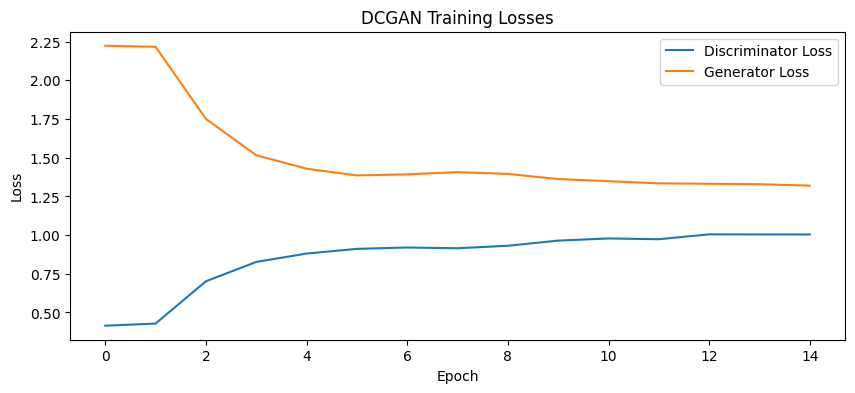

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(D_losses, label="Discriminator Loss")
plt.plot(G_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Losses")
plt.legend()
plt.show()


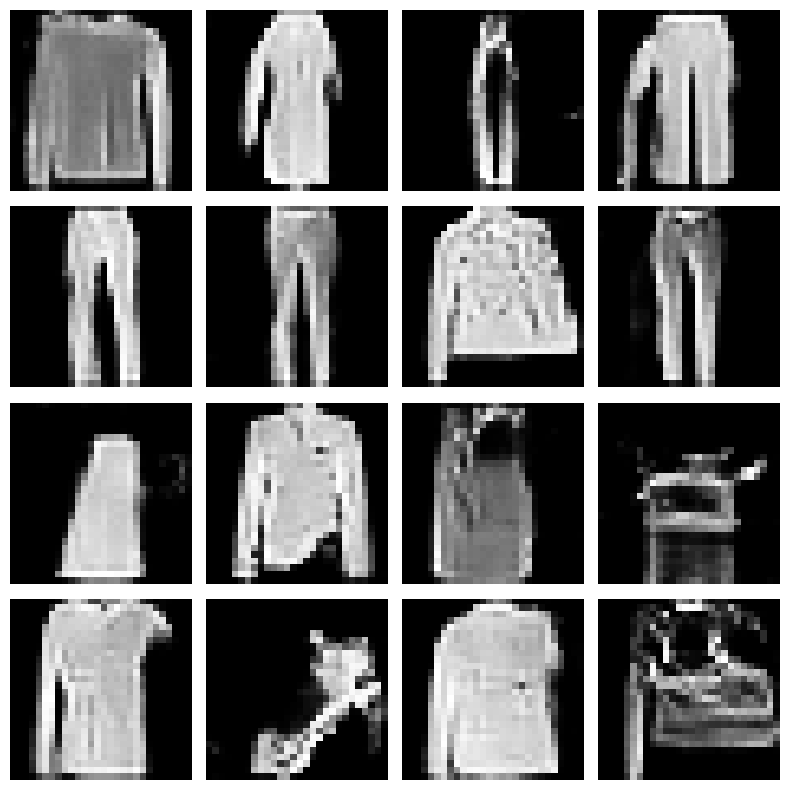

In [20]:
netG.load_state_dict(torch.load("dcgan_best_generator.pth"))
netG.eval()

with torch.no_grad():
    fake_images = netG(fixed_noise).cpu()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = fake_images[i].squeeze().numpy()
    img = (img * 0.5) + 0.5
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [21]:
def prepare_for_mifid(images):
    images = (images + 1) / 2
    images = images.clamp(0, 1)
    images = F.interpolate(images, size=(299, 299), mode="bilinear", align_corners=False)
    images = images.repeat(1, 3, 1, 1)
    images = (images * 255).to(torch.uint8)
    return images

mifid_metric_dcgan = MemorizationInformedFrechetInceptionDistance(feature=64).to(device)

netG.eval()
num_samples = 0
max_samples = 1000

with torch.no_grad():
    for real_images, _ in val_loader:
        real_images = real_images.to(device)
        b_size = real_images.size(0)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise)

        real_uint8 = prepare_for_mifid(real_images)
        fake_uint8 = prepare_for_mifid(fake_images)

        mifid_metric_dcgan.update(real_uint8, real=True)
        mifid_metric_dcgan.update(fake_uint8, real=False)

        num_samples += b_size
        if num_samples >= max_samples:
            break

dcgan_mifid = mifid_metric_dcgan.compute().item()
print("DCGAN MiFID:", dcgan_mifid)


DCGAN MiFID: 98.9251480102539


### Results and discussion

The DCGAN was introduced to test whether this adversarial learning could improve image compared with the VAE baseline. In this the generated outputs appeared  stronger and more detailed than the VAE samples.

Compared to the VAE the DCGAN produced more real looking  images which supports the idea that adversarial training can improve the quality.

The MiFID result is important in this section because it provides a  comparison against the VAE.  the score is lower than the VAE result this suggests that the DCGAN achieved a stronger overall performance

**Iteration 2 results**

- Final discriminator loss: 1.0040
- Final generator loss: 1.3195
- DCGAN MiFID: 98.9251


### Iteration 3: Wasserstein GAN with Gradient Penalty (WGAN-GP)


### Model design

The third model is a Wasserstein GAN with Gradient Penalty (WGAN-GP). This model was selected because it is a principled improvement over standard GAN training and was designed to improvethe stability.

### Motivation and hypothesis

The motivation for this iteration was to address the instability observed in the DCGAN model.

My hypothesis was that WGAN GP would produce more stable training behaviour than DCGAN and could potentially improve image quality further although this  still depend on hyperparameter choices.

### Training setup
The WGAN-GP model was trained on the same FashionMNIST dataset split and preprocessing pipeline used in the earlier iterations so that the evaluation is consistent across all three experiments.

In this setup the discriminator from DCGAN was replaced by a critic and a gradient penalty  was used during training. The critic was also updated multiple times per generator step following the usual WGAN-GP training strategy.


In [22]:
nz_wgan = 100
num_epochs_wgan = 15
lr_wgan = 0.0001
beta1_wgan = 0.0
beta2_wgan = 0.9
lambda_gp = 10
critic_iterations = 5


In [23]:
class WGANGenerator(nn.Module):
    def __init__(self):
        super(WGANGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz_wgan, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


class WGANCritic(nn.Module):
    def __init__(self):
        super(WGANCritic, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(128, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1)


In [24]:
def weights_init_wgan(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1 or classname.find("InstanceNorm") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

netG_wgan = WGANGenerator().to(device)
netC_wgan = WGANCritic().to(device)

netG_wgan.apply(weights_init_wgan)
netC_wgan.apply(weights_init_wgan)

optimizerG_wgan = optim.Adam(netG_wgan.parameters(), lr=lr_wgan, betas=(beta1_wgan, beta2_wgan))
optimizerC_wgan = optim.Adam(netC_wgan.parameters(), lr=lr_wgan, betas=(beta1_wgan, beta2_wgan))


In [25]:
def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    batch_size = real_samples.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolates = alpha * real_samples + ((1 - alpha) * fake_samples)
    interpolates.requires_grad_(True)

    critic_scores = critic(interpolates)

    gradients = torch.autograd.grad(
        outputs=critic_scores,
        inputs=interpolates,
        grad_outputs=torch.ones_like(critic_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty


In [26]:
G_losses_wgan = []
C_losses_wgan = []

fixed_noise_wgan = torch.randn(16, nz_wgan, 1, 1, device=device)

best_g_loss_wgan = float("inf")

for epoch in range(num_epochs_wgan):
    running_c = 0.0
    running_g = 0.0

    for i, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        batch_size_now = real_images.size(0)

        for _ in range(critic_iterations):
            noise = torch.randn(batch_size_now, nz_wgan, 1, 1, device=device)
            fake_images = netG_wgan(noise)

            optimizerC_wgan.zero_grad()

            critic_real = netC_wgan(real_images)
            critic_fake = netC_wgan(fake_images.detach())

            gp = compute_gradient_penalty(netC_wgan, real_images, fake_images.detach(), device)
            loss_critic = -(torch.mean(critic_real) - torch.mean(critic_fake)) + lambda_gp * gp

            loss_critic.backward()
            optimizerC_wgan.step()

            running_c += loss_critic.item()

        noise = torch.randn(batch_size_now, nz_wgan, 1, 1, device=device)
        fake_images = netG_wgan(noise)

        optimizerG_wgan.zero_grad()
        loss_generator = -torch.mean(netC_wgan(fake_images))
        loss_generator.backward()
        optimizerG_wgan.step()

        running_g += loss_generator.item()

    avg_c = running_c / (len(train_loader) * critic_iterations)
    avg_g = running_g / len(train_loader)

    C_losses_wgan.append(avg_c)
    G_losses_wgan.append(avg_g)

    if avg_g < best_g_loss_wgan:
        best_g_loss_wgan = avg_g
        torch.save(netG_wgan.state_dict(), "wgan_gp_best_generator.pth")
        torch.save(netC_wgan.state_dict(), "wgan_gp_best_critic.pth")

    print(f"Epoch [{epoch+1}/{num_epochs_wgan}] | Critic Loss: {avg_c:.4f} | Generator Loss: {avg_g:.4f}")


Epoch [1/15] | Critic Loss: -5.7358 | Generator Loss: -3.5036
Epoch [2/15] | Critic Loss: -5.2829 | Generator Loss: 6.3733
Epoch [3/15] | Critic Loss: -4.0351 | Generator Loss: 8.0730
Epoch [4/15] | Critic Loss: -3.4661 | Generator Loss: 8.7212
Epoch [5/15] | Critic Loss: -3.0970 | Generator Loss: 9.0656
Epoch [6/15] | Critic Loss: -2.8113 | Generator Loss: 9.2467
Epoch [7/15] | Critic Loss: -2.6090 | Generator Loss: 9.7036
Epoch [8/15] | Critic Loss: -2.4473 | Generator Loss: 10.2653
Epoch [9/15] | Critic Loss: -2.3210 | Generator Loss: 10.4888
Epoch [10/15] | Critic Loss: -2.2316 | Generator Loss: 10.7260
Epoch [11/15] | Critic Loss: -2.1413 | Generator Loss: 11.3410
Epoch [12/15] | Critic Loss: -2.0678 | Generator Loss: 11.5696
Epoch [13/15] | Critic Loss: -2.0050 | Generator Loss: 11.7579
Epoch [14/15] | Critic Loss: -1.9519 | Generator Loss: 11.8253
Epoch [15/15] | Critic Loss: -1.8904 | Generator Loss: 12.1234


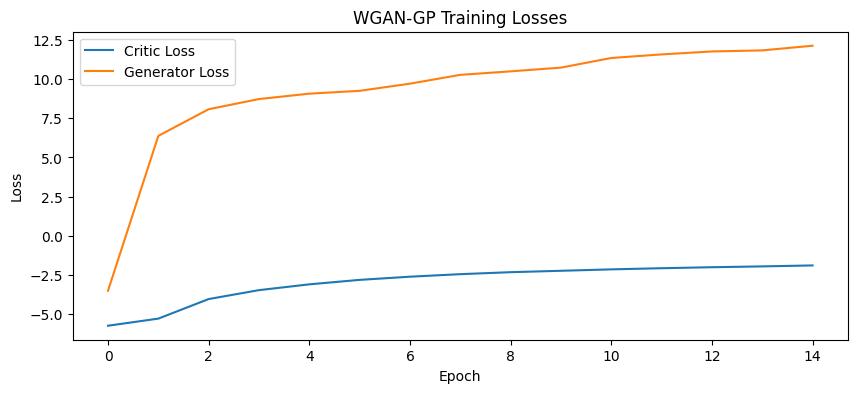

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(C_losses_wgan, label="Critic Loss")
plt.plot(G_losses_wgan, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN-GP Training Losses")
plt.legend()
plt.show()


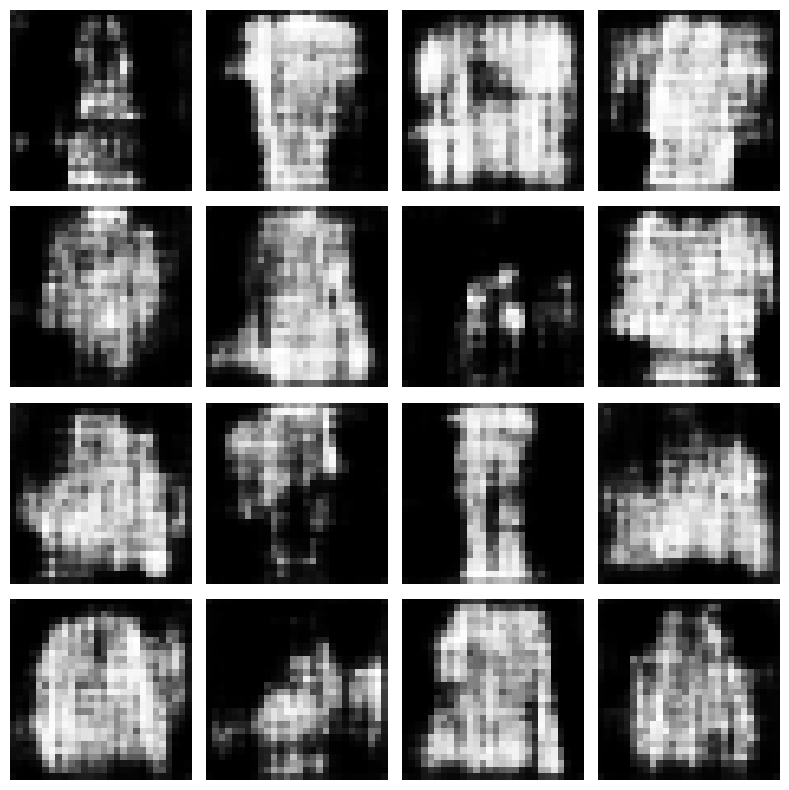

In [28]:
netG_wgan.load_state_dict(torch.load("wgan_gp_best_generator.pth"))
netG_wgan.eval()

with torch.no_grad():
    fake_images_wgan = netG_wgan(fixed_noise_wgan).cpu()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = fake_images_wgan[i].squeeze().numpy()
    img = (img * 0.5) + 0.5
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [29]:
def prepare_for_mifid(images):
    images = (images + 1) / 2
    images = images.clamp(0, 1)
    images = F.interpolate(images, size=(299, 299), mode="bilinear", align_corners=False)
    images = images.repeat(1, 3, 1, 1)
    images = (images * 255).to(torch.uint8)
    return images

mifid_metric_wgan = MemorizationInformedFrechetInceptionDistance(feature=64).to(device)

netG_wgan.eval()
num_samples = 0
max_samples = 1000

with torch.no_grad():
    for real_images, _ in val_loader:
        real_images = real_images.to(device)
        batch_size_now = real_images.size(0)

        noise = torch.randn(batch_size_now, nz_wgan, 1, 1, device=device)
        fake_images = netG_wgan(noise)

        real_uint8 = prepare_for_mifid(real_images)
        fake_uint8 = prepare_for_mifid(fake_images)

        mifid_metric_wgan.update(real_uint8, real=True)
        mifid_metric_wgan.update(fake_uint8, real=False)

        num_samples += batch_size_now
        if num_samples >= max_samples:
            break

wgan_mifid = mifid_metric_wgan.compute().item()
print("WGAN-GP MiFID:", wgan_mifid)


WGAN-GP MiFID: 894.5772705078125


### Results and discussion

The WGAN-GP model was introduced as a more stable improvement over the standard GAN setting. In this experiment, the critic based training approach aimed to reduce the instability .

 In the final results, WGAN-GP improved on the VAE baseline but did not outperform DCGAN on MiFID. This shows that the theoretically stronger training objective did not translate into the best overall result in this implementation



## Iteration 3 results

- Final critic loss: -1.8904
- Final generator loss: 12.1234
- WGAN-GP MiFID: 894.5772

## Summary and Recommendation


here we have compared three  generative model approaches on the FashionMNIST dataset a VAE a DCGAN and an WGAN-GP. The models were evaluated using both qualitative sample inspection and the MiFID metric.

The VAE provided the  stable and useful baseline but its outputs were a bit less sharp than those from the other 2  models. The DCGAN improved visual quality and achieved the strongest overall performance in this implementation. The WGAN-GP improved on the VAE baseline, but it did not outperform the DCGAN in the final results.

Based on these experiments it  can be  recommended that the DCGAN model as the strongest overall iteration here. It provided the best balance between visual quality and quantitative performance which showid that a simpler adversarial baseline can outperform a more advanced model.




## References


- Gulrajani, I., Ahmed, F., Arjovsky, M., Dumoulin, V. and Courville, A. (2017). Improved Training of Wasserstein GANs. arXiv:1704.00028. https://arxiv.org/abs/1704.00028

- Kingma, D.P. and Welling, M. (2013). Auto-Encoding Variational Bayes. arXiv:1312.6114. https://arxiv.org/abs/1312.6114

- Lightning AI (2026). Memorization-Informed Frechet Inception Distance (MiFID). https://lightning.ai/docs/torchmetrics/stable/image/mifid.html

- Radford, A., Metz, L. and Chintala, S. (2015). Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks. arXiv:1511.06434. https://arxiv.org/abs/1511.06434

- Xiao, H., Rasul, K. and Vollgraf, R. (2017). Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms. arXiv:1708.07747. https://arxiv.org/abs/1708.07747

